# зависимость относительный ошибки решения при относительном возмущении вектора b

In [19]:
import numpy as np

In [21]:
from lu_matrix_processor import LUMatrixProcessor


def practical_condition_number(A, b, eps=1e-8):
    processor = LUMatrixProcessor()
    processor.set_matrix(A, b)

    x = processor.solve_and_return_x()

    perturb = eps * np.linalg.norm(b, np.inf)
    b2 = b.copy()
    b2[0] += perturb

    processor.set_matrix(A, b2)
    x2 = processor.solve_and_return_x()

    rel_b = np.linalg.norm(b2 - b, np.inf) / np.linalg.norm(b, np.inf)
    rel_x = np.linalg.norm(x2 - x, np.inf) / np.linalg.norm(x, np.inf)

    k_pract = rel_x / rel_b
    return k_pract

In [22]:
A = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 2, 4, 8, 16, 32, 64, 128, 256, 512],
    [1, 3, 9, 27, 81, 243, 729, 2187, 6561, 19683],
    [1, 4, 16, 64, 256, 1024, 4096, 16384, 65536, 262144],
    [1, 5, 25, 125, 625, 3125, 15625, 78125, 390625, 1953125],
    [1, 6, 36, 216, 1296, 7776, 46656, 279936, 1679616, 10077696],
    [1, 7, 49, 343, 2401, 16807, 117649, 823543, 5764801, 40353607],
    [1, 8, 64, 512, 4096, 32768, 262144, 2097152, 16777216, 134217728],
    [1, 9, 81, 729, 6561, 59049, 531441, 4782969, 43046721, 387420489],
    [1, 10, 100, 1000, 10000, 100000, 1000000, 10000000, 100000000, 1000000000]
], dtype=float)

b = np.array([45, 8194, 250959, 3029220, 21362305, 106420470, 
              415866339, 1358612104, 3868151445, 9876543210], dtype=float)

k_theor = 1041528888784736 / 315 
k_pract = practical_condition_number(A, b)

percent = k_pract / k_theor * 100

print("Теоретическое число обусловленности:")
print(f"{k_theor}")

print("\nПрактическая оценка:")
print(f"{k_pract}")

print(f"{percent:.2f} %")


Теоретическое число обусловленности:
3306440916776.9395

Практическая оценка:
21168386204.80739
0.64 %


In [2]:
import matplotlib.pyplot as plt
import numpy as np

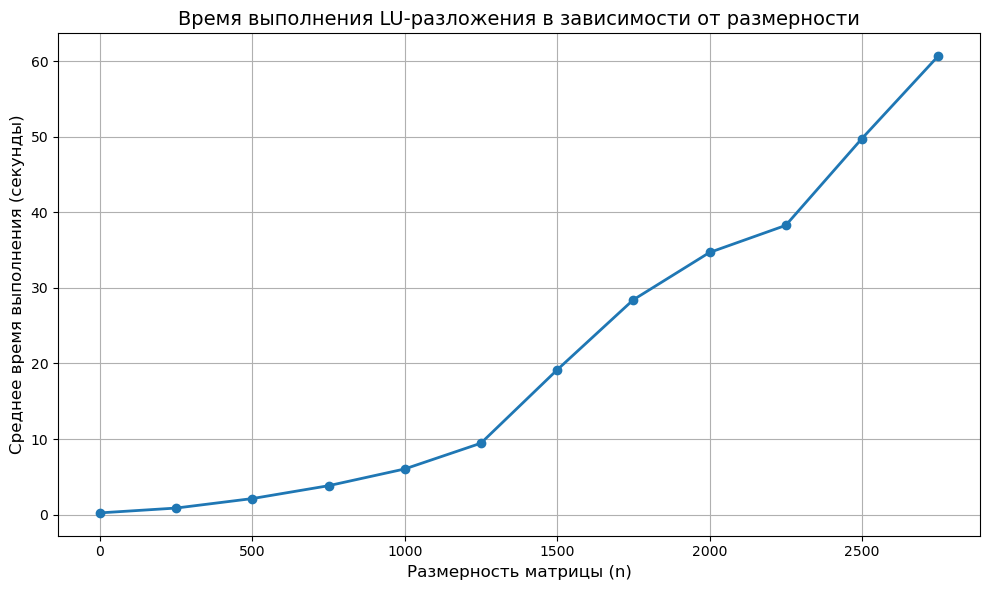

In [9]:
data = np.loadtxt('data/times.txt')

n_values = data[:, 0]
times = data[:, 1]

plt.figure(figsize=(10, 6))
plt.plot(n_values, times, '-o', linewidth=2)

plt.title("Время выполнения LU-разложения в зависимости от размерности", fontsize=14)
plt.xlabel("Размерность матрицы (n)", fontsize=12)
plt.ylabel("Среднее время выполнения (секунды)", fontsize=12)
plt.grid(True)
plt.tight_layout()

plt.show()
